In [16]:
from netCDF4 import Dataset
import os
os.chdir("/Users/rem76/Desktop/Climate_change_health/nex_gddp_cmip6_malawi_wbgt/ACCESS-CM2/ssp245")

In [17]:

nc = Dataset('wbgt_day_ACCESS-CM2_ssp245_malawi_2025_2040.nc', 'r')
print(nc.variables.keys())
print(nc.variables['time'])


dict_keys(['time', 'lat', 'lon', 'wbgt', 'tg', 'twb'])
<class 'netCDF4.Variable'>
float64 time(time)
    _FillValue: nan
    bounds: time_bnds
    standard_name: time
    long_name: time
    axis: T
    units: days since 1850-01-01
    calendar: proleptic_gregorian
unlimited dimensions: 
current shape = (5844,)
filling on


dict_keys(['time', 'lat', 'lon', 'wbgt', 'tg', 'twb'])


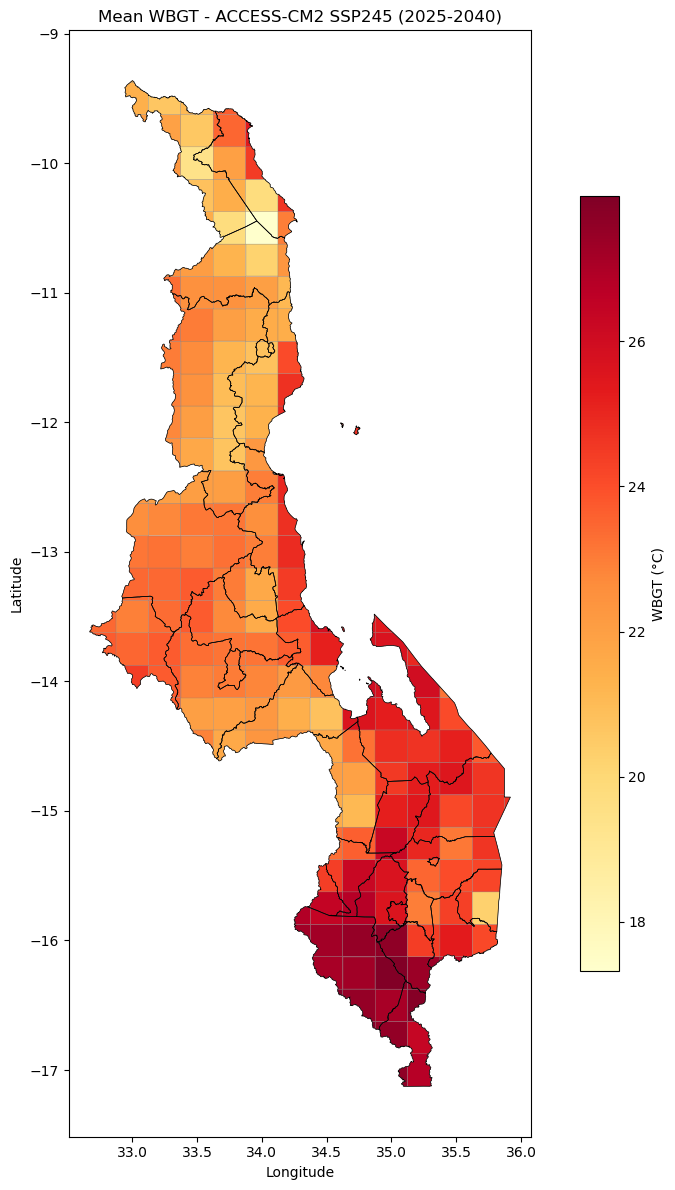

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset
from shapely.geometry import Polygon

# Load netCDF data
nc = Dataset('wbgt_day_ACCESS-CM2_ssp245_malawi_2025_2040.nc', 'r')
print(nc.variables.keys())

wbgt_data = nc.variables['wbgt'][:]  # adjust variable name if needed
lat_data = nc.variables['lat'][:]
lon_data = nc.variables['lon'][:]

# Get time variable and convert to datetime
time_var = nc.variables['time']
from netCDF4 import num2date
times = num2date(time_var[:], units=time_var.units, calendar=getattr(time_var, 'calendar', 'standard'))

# Get month for each timestep
months = np.array([t.month for t in times])

# Filter for Oct, Nov, Dec (months 10, 11, 12)
ond_mask = (months >= 10) & (months <= 12)

# Calculate mean over OND only
if wbgt_data.ndim == 3:
    wbgt_mean = np.mean(wbgt_data[ond_mask, :, :], axis=0)
else:
    wbgt_mean = wbgt_data
# Load Malawi shapefiles
malawi_admin2 = gpd.read_file(
    "/Users/rem76/PycharmProjects/TLOmodel/resources/mapping/ResourceFile_mwi_admbnda_adm2_nso_20181016.shp"
)

# Create grid polygons from netCDF coordinates
difference_lat = lat_data[1] - lat_data[0]
difference_lon = lon_data[1] - lon_data[0]

polygons = []
wbgt_values = []

for i, y in enumerate(lat_data):
    for j, x in enumerate(lon_data):
        bottom_left = (x, y)
        bottom_right = (x + difference_lon, y)
        top_right = (x + difference_lon, y + difference_lat)
        top_left = (x, y + difference_lat)
        polygon = Polygon([bottom_left, bottom_right, top_right, top_left])
        polygons.append(polygon)
        wbgt_values.append(wbgt_mean[i, j])

# Create GeoDataFrame with WBGT values
grid = gpd.GeoDataFrame({
    'geometry': polygons,
    'wbgt': wbgt_values
}, crs=malawi_admin2.crs)

# Clip grid to Malawi boundaries
grid_clipped = gpd.overlay(grid, malawi_admin2, how='intersection')

# Plot
fig, ax = plt.subplots(figsize=(10, 12))

# Plot clipped grid with WBGT values
grid_clipped.plot(column='wbgt', ax=ax, cmap='YlOrRd', 
                   edgecolor='grey', linewidth=0.2, legend=True,
                   legend_kwds={'label': 'WBGT (°C)', 'shrink': 0.7})

# Add district boundaries on top
malawi_admin2.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

plt.title('Mean WBGT - ACCESS-CM2 SSP245 (2025-2040)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('wbgt_map_clipped.png', dpi=150)
plt.show()

nc.close()

In [13]:

nc = Dataset('tas_day_ACCESS-CM2_ssp245_malawi_2025_2040.nc', 'r')
print(nc.variables.keys())
print(nc.variables['time'])

dict_keys(['tas', 'lon', 'time', 'lat'])
<class 'netCDF4.Variable'>
float64 time(time)
    _FillValue: nan
    bounds: time_bnds
    standard_name: time
    long_name: time
    axis: T
    units: days since 1850-01-01
    calendar: proleptic_gregorian
unlimited dimensions: 
current shape = (5844,)
filling on


In [14]:
nc

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    activity: NEX-GDDP-CMIP6
    Conventions: CF-1.7
    frequency: day
    institution: NASA Earth Exchange, NASA Ames Research Center, Moffett Field, CA 94035
    variant_label: r1i1p1f1
    product: output
    realm: atmos
    source: BCSD
    scenario: ssp245
    references: BCSD method: Thrasher et al., 2012, Hydrol. Earth Syst. Sci.,16, 3309-3314. Ref period obs: latest version of the Princeton Global Meteorological Forcings (http://hydrology.princeton.edu/data.php), based on Sheffield et al., 2006, J. Climate, 19 (13), 3088-3111.
    version: 2.0
    title: ACCESS-CM2, r1i1p1f1, ssp245, global downscaled CMIP6 climate projection data
    resolution_id: 0.25 degree
    external_variables: areacella
    cmip6_source_id: ACCESS-CM2
    cmip6_institution_id: CSIRO-ARCCSS
    cmip6_license: CC-BY-SA 4.0
    contact: Dr. Bridget Thrasher: bridget@climateanalyticsgroup.org, Dr. Ian Brosnan: ian.g.brosnan@nasa.

In [ ]:
 def assign_closest_facility_level(self):
        """Function that assigns an individual coordinates,
        and then the facilities at which they recieve care at each level."""
        # Load district polygons from shapefile
        gpd.read_file(Path(self.resourcefilepath / "mapping" / "ResourceFile_mwi_admbnda_adm2_nso_20181016.shp"))
        worldpop_gdf = gpd.read_file(
            Path(self.resourcefilepath / "climate_change_impacts" / "worldpop_density_with_districts.shp")
        )
        worldpop_gdf["Z_prop"] = pd.to_numeric(
            worldpop_gdf["Z_prop"], errors="coerce"
        )  # even when saved as numeric, read in as string

        def assign_coordinate_by_population_weight(district_name):
            """Assigns a coordinate within the district, weighted by population density (Z_proportion)."""
            subset = worldpop_gdf[worldpop_gdf["ADM2_EN"] == district_name]
            if subset.empty:
                return None
            chosen_point = subset.sample(weights="Z_prop").iloc[0]["geometry"]
            return chosen_point

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Load shapefiles
malawi_admin2 = gpd.read_file(
    "/Users/rem76/PycharmProjects/TLOmodel/resources/mapping/ResourceFile_mwi_admbnda_adm2_nso_20181016.shp"
)

worldpop_gdf = gpd.read_file(
    "/Users/rem76/PycharmProjects/TLOmodel/resources/climate_change_impacts/worldpop_density_with_districts.shp"
)
worldpop_gdf["Z_prop"] = pd.to_numeric(worldpop_gdf["Z_prop"], errors="coerce")

# Check CRS
print(f"malawi_admin2 CRS: {malawi_admin2.crs}")
print(f"worldpop_gdf CRS: {worldpop_gdf.crs}")

# Reproject worldpop to match admin boundaries if needed
if worldpop_gdf.crs != malawi_admin2.crs:
    worldpop_gdf = worldpop_gdf.to_crs(malawi_admin2.crs)
    print("Reprojected worldpop_gdf to match malawi_admin2")

# Plot
fig, ax = plt.subplots(figsize=(10, 12))

# Plot worldpop grid with population density
worldpop_gdf.plot(
    column="Z_prop",
    ax=ax,
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Population Density (Z_prop)", "shrink": 0.6},
)

# Overlay district boundaries
malawi_admin2.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8)

ax.set_title("WorldPop Population Density Grid")
ax.axis("off")

plt.tight_layout()
plt.show()

malawi_admin2 CRS: None
worldpop_gdf CRS: EPSG:4326


ValueError: Must pass either crs or epsg.